# HDB Resale Flat Valuation

This notebook estimates the fair market value of a Singapore HDB resale flat using three independent valuation approaches and blends them into a single point estimate and conservative range.

The subject property and comparable universe are configurable in the cell below — change the `SUBJECT_*` and `COMPARABLE_TOWNS` values to value any flat covered by the dataset. Inputs are validated against the loaded data, with errors that list valid values on typos.

## Data source

Live download of **Resale flat prices based on registration date from Jan-2017 onwards** from [data.gov.sg](https://data.gov.sg/datasets/d_8b84c4ee58e3cfc0ece0d773c8ca6abc/view).

**Caveats from HDB:**
- Approximate floor area includes any recess area purchased, space-adding items under upgrading programmes, roof terraces, and similar additions.
- The dataset excludes transactions that may not reflect the full market price (e.g., resale between relatives, resale of part shares).
- Resale prices are indicative only — actual sale prices depend on many factors not captured here.

In [30]:
# Retrive dataset ID from relevant .gov/sg dataset
DATASET_ID = "d_8b84c4ee58e3cfc0ece0d773c8ca6abc" # e.g. "DATA_SET_ID"

In [31]:
import json
import requests

s = requests.Session()
s.headers.update({"referer": "https://colab.research.google.com"})

BASE_URL = "https://api-production.data.gov.sg"
url = f"{BASE_URL}/v2/public/api/datasets/{DATASET_ID}/metadata"
response = s.get(url)

data = response.json()["data"]
column_metadata = data.pop("columnMetadata", None)

print("Dataset:", data["name"])
print(f"Coverage: {data['coverageStart'][:10]} to {data['coverageEnd'][:10]}")
print(f"Last updated: {data['lastUpdatedAt'][:10]}")
print(f"Columns: {list(column_metadata['map'].values())}")

Dataset: Resale flat prices based on registration date from Jan-2017 onwards
Coverage: 2017-01-01 to 2026-02-01
Last updated: 2026-02-25
Columns: ['month', 'town', 'flat_type', 'block', 'street_name', 'storey_range', 'floor_area_sqm', 'flat_model', 'lease_commence_date', 'remaining_lease', 'resale_price']


In [32]:
import time
import numpy as np
import pandas as pd


def download_file(dataset_id):
    """Download CSV from data.gov.sg and return as DataFrame."""
    s.get(
        f"https://api-open.data.gov.sg/v1/public/api/datasets/{dataset_id}/initiate-download",
        headers={"Content-Type": "application/json"},
        json={},
    )

    MAX_POLLS = 5
    for i in range(MAX_POLLS):
        resp = s.get(
            f"https://api-open.data.gov.sg/v1/public/api/datasets/{dataset_id}/poll-download",
            headers={"Content-Type": "application/json"},
            json={},
        )
        if "url" in resp.json()["data"]:
            df = pd.read_csv(resp.json()["data"]["url"])
            print(f"Loaded {len(df):,} rows")
            return df
        print(f"  Poll {i+1}/{MAX_POLLS} — waiting...")
        time.sleep(3)

    raise RuntimeError("Download timed out — try again or check data.gov.sg status.")


df = download_file(DATASET_ID)

Loaded 225,801 rows


In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

DJQC_RC = {
    "axes.facecolor": "#EBF8FF",
    "axes.edgecolor": "#333333",
    "axes.grid": False,
    "grid.color": "#FFFFFF",
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 8,
    "axes.titlesize": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7,
    "figure.titlesize": 10,
}

DJQC_COLORS = ["grey", "#785EF0", "#DC267F", "#FE6100", "#FFB000", "#44AA99", "#117733"]

sns.set_style("darkgrid", rc=DJQC_RC)
sns.set_palette(sns.color_palette(DJQC_COLORS))

In [ ]:
# ── User configuration ──────────────────────────────────────────────────────
# Subject property — the unit being valued.
SUBJECT_TOWN       = "QUEENSTOWN"           # must match HDB town names exactly
SUBJECT_FLAT_TYPE  = "4 ROOM"               # e.g. "3 ROOM", "4 ROOM", "5 ROOM", "EXECUTIVE"
SUBJECT_FLAT_MODEL = "Premium Apartment"    # e.g. "Model A", "Improved", "Premium Apartment"
SUBJECT_FLOOR      = 10                     # storey
SUBJECT_AREA_SQM   = 83                     # floor area in square metres
SUBJECT_LEASE_LEFT = 94.99                  # remaining lease in years
SUBJECT_STREET     = "DAWSON"               # substring matched against street_name (for the street-level highlight)

# Comparable universe for valuation. SUBJECT_TOWN is auto-added if missing.
# Use a single-element list (e.g. [SUBJECT_TOWN]) to restrict to the subject town only.
COMPARABLE_TOWNS = ["QUEENSTOWN", "BUKIT MERAH", "CENTRAL AREA"]

# ── Validate inputs against the loaded dataset ──────────────────────────────
SUBJECT_TOWN      = SUBJECT_TOWN.upper().strip()
SUBJECT_FLAT_TYPE = SUBJECT_FLAT_TYPE.upper().strip()
COMPARABLE_TOWNS  = [t.upper().strip() for t in COMPARABLE_TOWNS]

available_towns      = set(df["town"].unique())
available_models     = set(df["flat_model"].unique())
available_flat_types = set(df["flat_type"].unique())

unknown_towns = {SUBJECT_TOWN, *COMPARABLE_TOWNS} - available_towns
if unknown_towns:
    raise ValueError(
        f"Unknown town(s): {sorted(unknown_towns)}. "
        f"Available towns: {sorted(available_towns)}"
    )

if SUBJECT_FLAT_TYPE not in available_flat_types:
    raise ValueError(
        f"Unknown flat type {SUBJECT_FLAT_TYPE!r}. "
        f"Available flat types: {sorted(available_flat_types)}"
    )

if SUBJECT_FLAT_MODEL not in available_models:
    raise ValueError(
        f"Unknown flat model {SUBJECT_FLAT_MODEL!r}. "
        f"Available models: {sorted(available_models)}"
    )

if SUBJECT_FLOOR <= 0 or SUBJECT_AREA_SQM <= 0 or not (0 < SUBJECT_LEASE_LEFT <= 99):
    raise ValueError(
        f"SUBJECT_FLOOR (>0), SUBJECT_AREA_SQM (>0), SUBJECT_LEASE_LEFT (0–99) must be positive/in-range; "
        f"got {SUBJECT_FLOOR=}, {SUBJECT_AREA_SQM=}, {SUBJECT_LEASE_LEFT=}"
    )

if SUBJECT_TOWN not in COMPARABLE_TOWNS:
    print(f"Note: subject town {SUBJECT_TOWN!r} not in COMPARABLE_TOWNS; auto-adding.")
    COMPARABLE_TOWNS = [SUBJECT_TOWN, *COMPARABLE_TOWNS]

# Display-friendly label for plot/table titles, e.g. "4 ROOM" -> "4-Room",
# "EXECUTIVE" -> "Executive", "MULTI-GENERATION" -> "Multi-Generation".
SUBJECT_FLAT_TYPE_LABEL = SUBJECT_FLAT_TYPE.title().replace(" ", "-")

SELECTED_TOWNS = [SUBJECT_TOWN]  # used by exploratory cells below

# ── Feature engineering ─────────────────────────────────────────────────────
SQM_TO_SQFT = 10.7639

df["month"] = pd.to_datetime(df["month"])

df["remaining_lease_years"] = (
    df["remaining_lease"].str.extract(r"(\d+)").astype(float)
    + df["remaining_lease"].str.extract(r"\d+\s+years\s+(\d+)").astype(float) / 12
)
df["price_per_sqft"] = df["resale_price"] / (df["floor_area_sqm"] * SQM_TO_SQFT)
df["storey_mid"] = df["storey_range"].apply(
    lambda x: np.mean([int(s) for s in x.split(" TO ")])
)


In [ ]:
is_subject_type = df["flat_type"] == SUBJECT_FLAT_TYPE
is_selected_town = df["town"].isin(SELECTED_TOWNS)
is_recent = df["month"].dt.year >= 2024

df_subject_full      = df.loc[is_subject_type & is_selected_town]   # subject town, all years
df_all_recent        = df.loc[is_subject_type & is_recent]           # all towns, 2024+
df_subject_recent    = df_subject_full.loc[is_recent]                # subject town, 2024+


In [ ]:
plt.figure(figsize=(9, 5))

town_colors = {
    town: DJQC_COLORS[1] if town == SUBJECT_TOWN else "grey"
    for town in df_all_recent["town"].unique()
}

sns.boxenplot(
    data=df_all_recent, x="town", y="resale_price",
    hue="town", palette=town_colors, dodge=False,
)
plt.title(f"Flat Prices across Towns from 2024 onwards ({SUBJECT_FLAT_TYPE_LABEL} Flats)")
plt.xlabel("Town")
plt.ylabel("Resale Price")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [ ]:
time_series = df_subject_full.groupby("month")["resale_price"].agg(
    ["median", lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]
)
time_series.columns = ["median", "Q1", "Q3"]
time_series["rolling_avg"] = time_series["median"].rolling(window=6).mean()

plt.figure(figsize=(9, 5))
plt.plot(time_series.index, time_series["median"], marker="o", label="Median", color=DJQC_COLORS[1], linewidth=2)
plt.plot(time_series.index, time_series["Q1"], marker="o", label="Q1", color="grey", linestyle=":", linewidth=1.5)
plt.plot(time_series.index, time_series["Q3"], marker="o", label="Q3", color="grey", linestyle=":", linewidth=1.5)
plt.plot(time_series.index, time_series["rolling_avg"], marker="o", label="6-Mo Rolling Avg", color="red", linestyle="--", linewidth=2)
plt.title(f"Resale Price of {SUBJECT_TOWN.title()} ({SUBJECT_FLAT_TYPE_LABEL} Flats)")
plt.xlabel("Month")
plt.ylabel("Resale Price")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [ ]:
df_plot = df_subject_recent.dropna(subset=["remaining_lease_years"])

plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df_plot, x="remaining_lease_years", y="resale_price",
    hue="flat_model", palette=DJQC_COLORS[1:],
    s=25, alpha=0.7,
)
plt.title(f"Flat Prices in {SUBJECT_TOWN.title()} ({SUBJECT_FLAT_TYPE_LABEL} Flats); 2024 onwards")
plt.xlabel("Remaining lease (Years)")
plt.ylabel("Resale price")
plt.legend(title="Flat Model", fontsize=8, title_fontsize=8, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [39]:
from great_tables import *
import polars as pl
import polars.selectors as cs

In [ ]:
DISPLAY_COLS = [
    "month", "block", "street_name", "storey_range", "resale_price",
    "floor_area_sqm", "price_per_sqft", "flat_model", "remaining_lease_years",
]

transactions_2026 = (
    df.loc[
        (df["town"] == SUBJECT_TOWN)
        & (df["month"].dt.year == 2026)
        & (df["flat_type"] == SUBJECT_FLAT_TYPE)
        & (df["street_name"].str.contains(SUBJECT_STREET))
    ][DISPLAY_COLS]
    .sort_values("month", ascending=False)
    .reset_index(drop=True)
)


In [41]:

fy2026_dawson = (
    GT(transactions_2026)
  .tab_header(title="FY 2026 Transactions", subtitle='Selected areas')
  .tab_stub(groupname_col="street_name", rowname_col="month")
  .cols_label( # Rename columns using cols_label()
      month="Transaction Month",
      block="Block",
      street_name="Street Name",
      storey_range="Storey Range",
      resale_price="Resale Price",
      floor_area_sqm="Area (sqm)",
      price_per_sqft="Price/sqft",
      flat_model="Flat Model",
      remaining_lease_years="Lease Left"
  )
  .data_color(
    columns=["resale_price"],
    domain = [400000, 1400000],
    palette=["lightgrey", 'lightblue', "green"]
  )
  .data_color(
    columns=["price_per_sqft"],
    domain = [500, 1400],
    palette=["lightgrey", 'lightblue', "green"]
  )
  .opt_table_font(font="Arial Narrow")
  .fmt_date(columns="month", date_style="month") # Update column name in fmt_date()
  .fmt_number(columns=["resale_price", "price_per_sqft"], compact=True) # Update column names in fmt_number()
  .fmt_number(columns=["remaining_lease_years"], decimals=2) # Update column names in fmt_number()
  .cols_align(align="left")
)

fy2026_dawson

GT(_tbl_data=        month block street_name storey_range  resale_price  floor_area_sqm  \
0  2026-02-01    86   DAWSON RD     04 TO 06     1015000.0            87.0   
1  2026-02-01    79   DAWSON RD     28 TO 30     1145000.0            88.0   
2  2026-02-01    93   DAWSON RD     28 TO 30     1270000.0            95.0   
3  2026-02-01    86   DAWSON RD     28 TO 30     1120000.0            83.0   
4  2026-02-01    91   DAWSON RD     16 TO 18     1070000.0            83.0   
5  2026-01-01    90   DAWSON RD     19 TO 21     1112100.0            83.0   
6  2026-01-01    90   DAWSON RD     37 TO 39     1330888.0            97.0   
7  2026-01-01    86   DAWSON RD     28 TO 30     1188888.0            83.0   
8  2026-01-01    86   DAWSON RD     40 TO 42     1150000.0            87.0   
9  2026-01-01    92   DAWSON RD     25 TO 27     1155000.0            87.0   
10 2026-01-01    79   DAWSON RD     19 TO 21     1130000.0            88.0   
11 2026-01-01    87   DAWSON RD     10 TO 12     1010000.0            83.0   
12 2026-01-01    92   DAWSON RD     19 TO 21     1258000.0            95.0   
13 2026-01-01    88   DAWSON RD     19 TO 21     1030000.0            83.0   
14 2026-01-01    89   DAWSON RD     10 TO 12     1100000.0            97.0   
15 2026-01-01    79   DAWSON RD     31 TO 33     1130000.0            88.0   
16 2026-01-01    78   DAWSON RD     01 TO 03      958000.0            88.0   
17 2026-01-01    86   DAWSON RD     43 TO 45     1215000.0            83.0   

    price_per_sqft              flat_model  remaining_lease_years  
0      1083.869849       Premium Apartment              89.500000  
1      1208.796406                 Model A              93.833333  
2      1241.968158  Premium Apartment Loft              89.250000  
3      1253.632596       Premium Apartment              89.583333  
4      1197.666855       Premium Apartment              89.250000  
5      1244.790009       Premium Apartment              89.416667  
6      1274.676915  Premium Apartment Loft              89.250000  
7      1330.739956       Premium Apartment              89.583333  
8      1228.029878       Premium Apartment              89.583333  
9      1233.369138       Premium Apartment              89.333333  
10     1192.960645                 Model A              93.916667  
11     1130.507966       Premium Apartment              89.666667  
12     1230.233025  Premium Apartment Loft              89.333333  
13     1152.894263       Premium Apartment              89.666667  
14     1053.540648  Premium Apartment Loft              89.333333  
15     1192.960645                 Model A              93.916667  
16     1011.377255                 Model A              93.916667  
17     1359.967504       Premium Apartment              89.583333  , _body=<great_tables._gt_data.Body object at 0x137840e50>, _boxhead=Boxhead([ColInfo(var='month', type=<ColInfoTypeEnum.stub: 2>, column_label='Transaction Month', column_align='left', column_width=None), ColInfo(var='block', type=<ColInfoTypeEnum.default: 1>, column_label='Block', column_align='left', column_width=None), ColInfo(var='street_name', type=<ColInfoTypeEnum.row_group: 3>, column_label='Street Name', column_align='left', column_width=None), ColInfo(var='storey_range', type=<ColInfoTypeEnum.default: 1>, column_label='Storey Range', column_align='left', column_width=None), ColInfo(var='resale_price', type=<ColInfoTypeEnum.default: 1>, column_label='Resale Price', column_align='left', column_width=None), ColInfo(var='floor_area_sqm', type=<ColInfoTypeEnum.default: 1>, column_label='Area (sqm)', column_align='left', column_width=None), ColInfo(var='price_per_sqft', type=<ColInfoTypeEnum.default: 1>, column_label='Price/sqft', column_align='left', column_width=None), ColInfo(var='flat_model', type=<ColInfoTypeEnum.default: 1>, column_label='Flat Model', column_align='left', column_width=None), ColInfo(var='remaining_lease_years', type=<ColInfoTypeEnum.default: 1>, column_label='Lease Le

## Fair Value Analysis

The cells below run three independent valuation approaches against the **subject property** and **comparable universe** defined in the configuration cell at the top of the notebook:

| Input | Source |
|---|---|
| Subject town, flat type, flat model, floor, area, lease, street | `SUBJECT_*` configuration variables |
| Comparable towns | `COMPARABLE_TOWNS` |
| Comparable flat models | `INCLUDED_MODELS` (set in the cell directly below) |

The comparable universe is restricted to **2024+ transactions** so the valuation reflects current market conditions rather than the full historical sweep.

### The three approaches

1. **Historical Comparables** — pick the 20 transactions most similar to the subject (weighted distance over floor, lease, area), then adjust each comp's price to the subject's exact attributes. Take the median.
2. **Regression with time trend** — OLS on the comparable universe with `floor_area_sqm`, `storey_mid`, `remaining_lease_years`, `months_since_2024`, plus one-hot `town` and `flat_model`. The time feature captures recent appreciation.
3. **Regression without time trend** — same model, time feature dropped. Treats all 2024+ transactions as equally current; useful as a sensitivity check against (2).

The three point estimates are averaged into a **blended fair value**, and the conservative range spans the widest of the three confidence intervals.

In [ ]:
# ── Subject property ─────────────────────────────────────────────────────────
# Values come from the user-configuration cell near the top of the notebook.
SUBJECT = {
    "town":       SUBJECT_TOWN,
    "flat_type":  SUBJECT_FLAT_TYPE,
    "flat_model": SUBJECT_FLAT_MODEL,
    "floor":      SUBJECT_FLOOR,
    "area_sqm":   SUBJECT_AREA_SQM,
    "lease_left": SUBJECT_LEASE_LEFT,
    "street":     SUBJECT_STREET,
}

# ── Comparable universe ──────────────────────────────────────────────────────
# COMPARABLE_TOWNS is also set in the user-configuration cell.
INCLUDED_MODELS = ["Model A", "Premium Apartment"]

df_comp = df.loc[
    (df["flat_type"] == SUBJECT_FLAT_TYPE)
    & (df["town"].isin(COMPARABLE_TOWNS))
    & (df["flat_model"].isin(INCLUDED_MODELS))
].copy()

df_comp_recent = df_comp.loc[df_comp["month"].dt.year >= 2024].copy()

print(f"Comparable towns: {COMPARABLE_TOWNS}")
print(f"Full comparable universe (2017-2026):  {len(df_comp):,} txns")
print(f"Recent comparables (2024+):            {len(df_comp_recent):,} txns")
print(f"\nBy town:\n{df_comp_recent['town'].value_counts().to_string()}")
print(f"\nBy model:\n{df_comp_recent['flat_model'].value_counts().to_string()}")


### Approach 1 — Historical Comparables

Pick the 20 transactions most similar to the subject (weighted distance on floor, lease, and area), then adjust each comparable's sale price to the subject's exact attributes. The point estimate is the median adjusted price across those 20 comps.

Adjustment rates are univariate OLS slopes fit on the comparable universe:

- **Floor-level premium** — $/floor
- **Lease premium** — $/year of remaining lease
- **Area adjustment** — $/sqm difference
- **Time adjustment** — $/month of market appreciation between the comp's transaction date and the valuation month

In [43]:
from scipy import stats

factors = {}

for label, x_col in [
    ("Floor-level ($/floor)", "storey_mid"),
    ("Lease ($/year)", "remaining_lease_years"),
    ("Area ($/sqm)", "floor_area_sqm"),
]:
    subset = df_comp_recent.dropna(subset=[x_col])
    slope, _, r, p, _ = stats.linregress(subset[x_col], subset["resale_price"])
    factors[label.split()[0].lower()] = slope
    print(f"{label:<25s}  ${slope:>10,.0f}   (R²={r**2:.3f}, p={p:.2e})")

# Monthly appreciation
df_time = df_comp_recent.copy()
df_time["months_since_2024"] = (df_time["month"].dt.year - 2024) * 12 + df_time["month"].dt.month
slope_t, _, r_t, p_t, _ = stats.linregress(df_time["months_since_2024"], df_time["resale_price"])
factors["time"] = slope_t
print(f"{'Time ($/month)':<25s}  ${slope_t:>10,.0f}   (R²={r_t**2:.3f}, p={p_t:.2e})")

Floor-level ($/floor)      $     7,345   (R²=0.362, p=4.32e-123)
Lease ($/year)             $     7,876   (R²=0.324, p=2.02e-98)
Area ($/sqm)               $    -5,849   (R²=0.083, p=5.02e-25)
Time ($/month)             $     3,473   (R²=0.044, p=8.18e-14)


In [44]:
VALUATION_MONTH = (2026 - 2024) * 12 + 2  # Feb 2026 = month 26

df_candidates = df_comp_recent.dropna(subset=["remaining_lease_years"]).copy()
df_candidates["months_since_2024"] = (
    (df_candidates["month"].dt.year - 2024) * 12 + df_candidates["month"].dt.month
)

# Weighted similarity score
df_candidates["similarity"] = (
    abs(df_candidates["storey_mid"] - SUBJECT["floor"]) * 2
    + abs(df_candidates["remaining_lease_years"] - SUBJECT["lease_left"]) * 1
    + abs(df_candidates["floor_area_sqm"] - SUBJECT["area_sqm"]) * 0.5
)

top_comps = df_candidates.nsmallest(20, "similarity").copy()

# Adjust each comp to the subject's attributes
for attr, col, factor_key in [
    ("floor", "storey_mid", "floor-level"),
    ("lease_left", "remaining_lease_years", "lease"),
    ("area_sqm", "floor_area_sqm", "area"),
]:
    top_comps[f"adj_{factor_key}"] = (SUBJECT[attr] - top_comps[col]) * factors[factor_key]

top_comps["adj_time"] = (VALUATION_MONTH - top_comps["months_since_2024"]) * factors["time"]
top_comps["total_adjustment"] = top_comps[["adj_floor-level", "adj_lease", "adj_area", "adj_time"]].sum(axis=1)
top_comps["adjusted_price"] = top_comps["resale_price"] + top_comps["total_adjustment"]

print(f"Top 20 comparables — adjusted price statistics:")
for stat, val in [
    ("Mean", top_comps["adjusted_price"].mean()),
    ("Median", top_comps["adjusted_price"].median()),
    ("Std", top_comps["adjusted_price"].std()),
    ("Range", None),
]:
    if stat == "Range":
        print(f"  {stat:<8s} ${top_comps['adjusted_price'].min():>12,.0f} — ${top_comps['adjusted_price'].max():>12,.0f}")
    else:
        print(f"  {stat:<8s} ${val:>12,.0f}")

Top 20 comparables — adjusted price statistics:
  Mean     $   1,038,729
  Median   $   1,036,494
  Std      $      34,113
  Range    $     968,169 — $   1,117,046


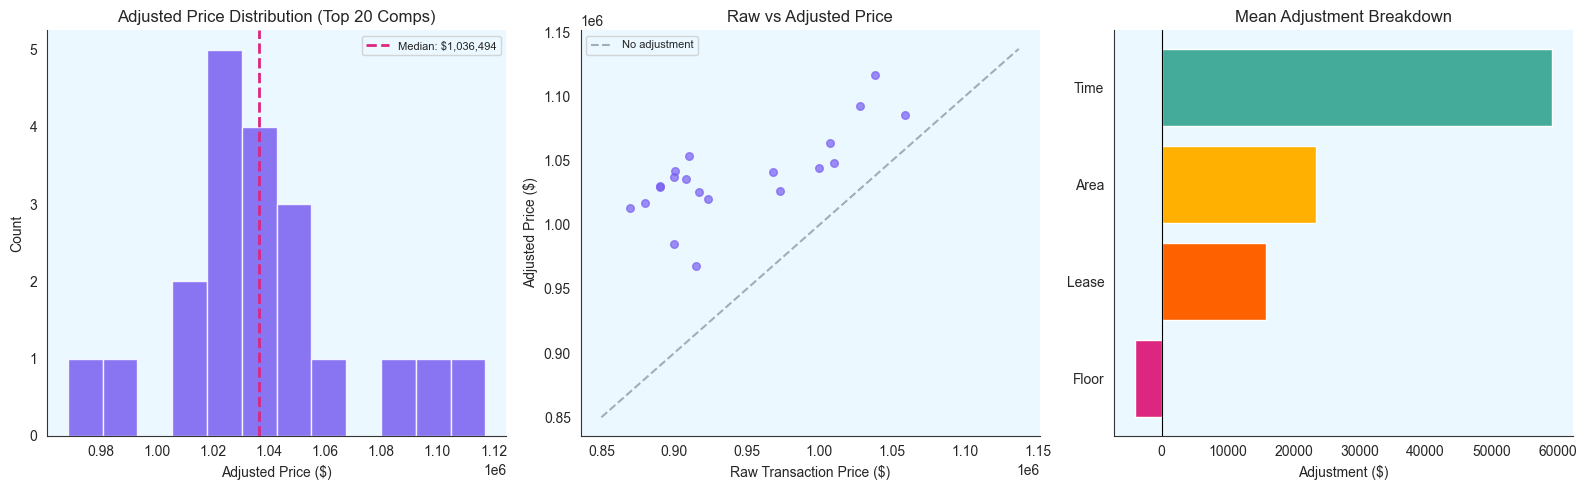

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Adjusted price distribution
axes[0].hist(top_comps["adjusted_price"], bins=12, color=DJQC_COLORS[1], edgecolor="white", alpha=0.85)
axes[0].axvline(
    top_comps["adjusted_price"].median(), color=DJQC_COLORS[2], linestyle="--", linewidth=2,
    label=f"Median: ${top_comps['adjusted_price'].median():,.0f}",
)
axes[0].set_title("Adjusted Price Distribution (Top 20 Comps)")
axes[0].set_xlabel("Adjusted Price ($)")
axes[0].set_ylabel("Count")
axes[0].legend(fontsize=8)

# 2. Raw vs adjusted
axes[1].scatter(top_comps["resale_price"], top_comps["adjusted_price"], color=DJQC_COLORS[1], s=30, alpha=0.7)
lims = [
    min(top_comps["resale_price"].min(), top_comps["adjusted_price"].min()) - 20_000,
    max(top_comps["resale_price"].max(), top_comps["adjusted_price"].max()) + 20_000,
]
axes[1].plot(lims, lims, "k--", alpha=0.3, label="No adjustment")
axes[1].set_title("Raw vs Adjusted Price")
axes[1].set_xlabel("Raw Transaction Price ($)")
axes[1].set_ylabel("Adjusted Price ($)")
axes[1].legend(fontsize=8)

# 3. Adjustment breakdown
adj_cols = ["adj_floor-level", "adj_lease", "adj_area", "adj_time"]
adj_means = top_comps[adj_cols].mean()
axes[2].barh(
    ["Floor", "Lease", "Area", "Time"], adj_means.values,
    color=[DJQC_COLORS[2], DJQC_COLORS[3], DJQC_COLORS[4], DJQC_COLORS[5]],
)
axes[2].axvline(0, color="black", linewidth=0.8)
axes[2].set_title("Mean Adjustment Breakdown")
axes[2].set_xlabel("Adjustment ($)")

plt.tight_layout()
plt.show()

In [46]:
# ── Comparables table ───────────────────────────────────────────────────────

comp_display = top_comps[[
    'month', 'town', 'block', 'street_name', 'storey_range',
    'floor_area_sqm', 'remaining_lease_years', 'flat_model',
    'resale_price', 'total_adjustment', 'adjusted_price'
]].sort_values('month', ascending=False).reset_index(drop=True)

comp_gt = (
    GT(comp_display)
    .tab_header(
        title="Approach 1 — Comparable Transactions (Adjusted)",
        subtitle="Top 20 closest comps · Model A & Premium Apartment · 2024 onwards"
    )
    .cols_label(
        month="Month", town="Town", block="Blk", street_name="Street",
        storey_range="Floor", floor_area_sqm="Area (sqm)",
        remaining_lease_years="Lease Left", flat_model="Model",
        resale_price="Raw Price", total_adjustment="Adj.",
        adjusted_price="Adjusted Price"
    )
    .data_color(
        columns=["adjusted_price"],
        domain=[comp_display['adjusted_price'].min(), comp_display['adjusted_price'].max()],
        palette=["lightgrey", "lightblue", "green"]
    )
    .opt_table_font(font="Arial Narrow")
    # .fmt_date(columns="month", date_style="month")
    .fmt_number(columns=["resale_price", "total_adjustment", "adjusted_price"], compact=True)
    .fmt_number(columns=["remaining_lease_years"], decimals=1)
    .cols_align(align="left")
)

comp_gt

GT(_tbl_data=        month         town block          street_name storey_range  \
0  2026-01-01   QUEENSTOWN    87            DAWSON RD     10 TO 12   
1  2025-11-01   QUEENSTOWN    88            DAWSON RD     10 TO 12   
2  2025-08-01  BUKIT MERAH   95B         HENDERSON RD     07 TO 09   
3  2025-06-01   QUEENSTOWN    88            DAWSON RD     10 TO 12   
4  2025-05-01   QUEENSTOWN    78            DAWSON RD     07 TO 09   
5  2025-05-01   QUEENSTOWN    53       STRATHMORE AVE     10 TO 12   
6  2025-02-01   QUEENSTOWN    78            DAWSON RD     10 TO 12   
7  2024-12-01  BUKIT MERAH   95A         HENDERSON RD     10 TO 12   
8  2024-05-01  BUKIT MERAH   95A         HENDERSON RD     10 TO 12   
9  2024-04-01   QUEENSTOWN    86            DAWSON RD     10 TO 12   
10 2024-04-01  BUKIT MERAH   90B  TELOK BLANGAH ST 31     10 TO 12   
11 2024-04-01  BUKIT MERAH   92B  TELOK BLANGAH ST 31     10 TO 12   
12 2024-03-01  BUKIT MERAH   90A  TELOK BLANGAH ST 31     10 TO 12   
13 2024-03-01  BUKIT MERAH   91A  TELOK BLANGAH ST 31     10 TO 12   
14 2024-03-01  BUKIT MERAH   92B  TELOK BLANGAH ST 31     10 TO 12   
15 2024-02-01  BUKIT MERAH   93A  TELOK BLANGAH ST 31     10 TO 12   
16 2024-02-01  BUKIT MERAH   93B  TELOK BLANGAH ST 31     10 TO 12   
17 2024-01-01   QUEENSTOWN    93            DAWSON RD     10 TO 12   
18 2024-01-01  BUKIT MERAH   95B         HENDERSON RD     10 TO 12   
19 2024-01-01   QUEENSTOWN    88            DAWSON RD     07 TO 09   

    floor_area_sqm  remaining_lease_years         flat_model  resale_price  \
0             83.0              89.666667  Premium Apartment     1010000.0   
1             83.0              89.750000  Premium Apartment     1000000.0   
2             83.0              92.750000            Model A      915000.0   
3             83.0              90.333333  Premium Apartment     1006888.0   
4             88.0              94.500000            Model A     1038000.0   
5             83.0              94.666667  Premium Apartment     1058888.0   
6             88.0              94.833333            Model A     1028000.0   
7             83.0              93.500000            Model A      973000.0   
8             83.0              94.083333            Model A      968000.0   
9             83.0              91.416667  Premium Apartment      923000.0   
10            93.0              93.750000            Model A      880000.0   
11            93.0              93.750000            Model A      900000.0   
12            93.0              93.916667            Model A      890000.0   
13            93.0              93.833333            Model A      890000.0   
14            93.0              93.750000            Model A      900888.0   
15            93.0              93.916667            Model A      870000.0   
16            93.0              93.833333            Model A      910000.0   
17            83.0              91.333333  Premium Apartment      916888.0   
18            83.0              94.333333            Model A      900000.0   
19            83.0              91.666667  Premium Apartment      908000.0   

    total_adjustment  adjusted_price  
0       38056.770206    1.048057e+06  
1       44345.659873    1.044346e+06  
2       53169.337813    9.681693e+05  
3       57114.196837    1.064002e+06  
4       79046.273611    1.117046e+06  
5       26455.332561    1.085343e+06  
6       64803.392107    1.092803e+06  
7       53007.743142    1.026008e+06  
8       72721.544708    1.040722e+06  
9       97198.174902    1.020198e+06  
10     137305.501771    1.017306e+06  
11     137305.501771    1.037306e+06  
12     139465.384203    1.029465e+06  
13     140121.759137    1.030122e+06  
14     140778.134071    1.041666e+06  
15     142938.016504    1.012938e+06  
16     143594.391438    1.053594e+06  
17     108272.446738    1.025160e+06  
18      84642.949108    9.846429e+05  
19     127682.225670    1.035682e+06  , _body=<great_tables._gt_data.Body object at 0x13396fa90>,

In [47]:
comp_estimate = top_comps["adjusted_price"].median()

print(f"APPROACH 1 — HISTORICAL COMPARABLES")
print(f"  Fair value (median):   ${comp_estimate:>12,.0f}")
print(f"  IQR:                   ${top_comps['adjusted_price'].quantile(0.25):>10,.0f} — ${top_comps['adjusted_price'].quantile(0.75):>10,.0f}")
print(f"  Price per sqft:        ${comp_estimate / (SUBJECT['area_sqm'] * SQM_TO_SQFT):>10,.0f}")

APPROACH 1 — HISTORICAL COMPARABLES
  Fair value (median):   $   1,036,494
  IQR:                   $ 1,023,920 — $ 1,049,441
  Price per sqft:        $     1,160


### Approach 2a — Regression Model (with time trend)

OLS regression trained on the recent (2024+) comparable universe.

**Features:**
- `floor_area_sqm`, `storey_mid`, `remaining_lease_years` — numeric
- `months_since_2024` — captures recent market appreciation
- `town`, `flat_model` — one-hot encoded

Numeric features are standardised before fitting (avoids matmul overflow when un-scaled values span many orders of magnitude).

In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error

df_reg = df_comp_recent.dropna(subset=["remaining_lease_years"]).copy()
df_reg["months_since_2024"] = (df_reg["month"].dt.year - 2024) * 12 + df_reg["month"].dt.month

NUM_COLS = ["floor_area_sqm", "storey_mid", "remaining_lease_years", "months_since_2024"]
CAT_COLS = ["town", "flat_model"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), NUM_COLS),
    ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), CAT_COLS),
])

reg_model = Pipeline([("preprocessor", preprocessor), ("regressor", LinearRegression())])
reg_model.fit(df_reg[NUM_COLS + CAT_COLS], df_reg["resale_price"])

y_pred = reg_model.predict(df_reg[NUM_COLS + CAT_COLS])
r2 = r2_score(df_reg["resale_price"], y_pred)
mae = mean_absolute_error(df_reg["resale_price"], y_pred)

print(f"Approach 2a — OLS with time trend (n={len(df_reg):,})")
print(f"  R²:  {r2:.4f}")
print(f"  MAE: ${mae:,.0f}")

Approach 2a — OLS with time trend (n=1,135)
  R²:  0.6141
  MAE: $60,519


/Users/djc/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/djc/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/djc/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [49]:
regressor = reg_model.named_steps["regressor"]
scaler = reg_model.named_steps["preprocessor"].named_transformers_["num"]
ohe = reg_model.named_steps["preprocessor"].named_transformers_["cat"]

num_coefs = regressor.coef_[:len(NUM_COLS)] / scaler.scale_
cat_names = list(ohe.get_feature_names_out(CAT_COLS))
cat_coefs = regressor.coef_[len(NUM_COLS):]

coef_df = pd.DataFrame({
    "Feature": NUM_COLS + cat_names,
    "Coefficient": list(num_coefs) + list(cat_coefs),
}).sort_values("Coefficient", key=abs, ascending=False)

print("Feature Coefficients (original units):")
print(coef_df.to_string(index=False, float_format="${:>12,.0f}".format))
print(f"\nIntercept: ${regressor.intercept_:,.0f}")

Feature Coefficients (original units):
                     Feature   Coefficient
           town_CENTRAL AREA $     -45,227
flat_model_Premium Apartment $      30,931
             town_QUEENSTOWN $      18,686
       remaining_lease_years $       6,810
                  storey_mid $       5,402
           months_since_2024 $       4,319
              floor_area_sqm $       1,997

Intercept: $929,742


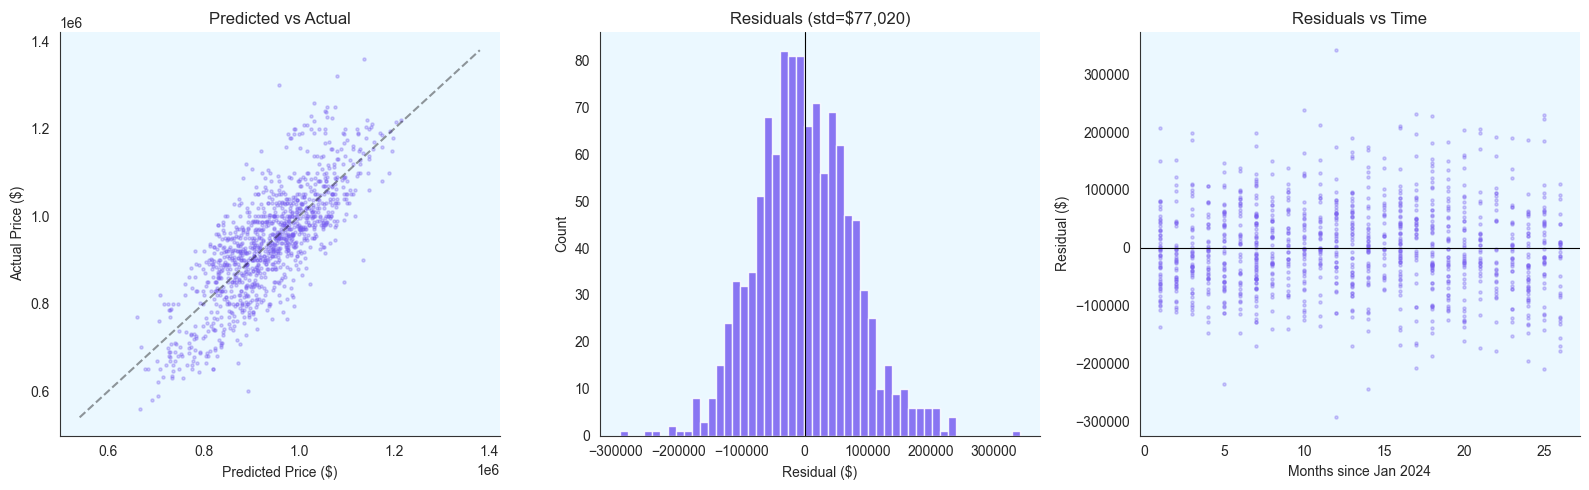

In [50]:
residuals = df_reg["resale_price"] - y_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(y_pred, df_reg["resale_price"], s=5, alpha=0.3, color=DJQC_COLORS[1])
lims = [df_reg["resale_price"].min() - 20_000, df_reg["resale_price"].max() + 20_000]
axes[0].plot(lims, lims, "k--", alpha=0.4)
axes[0].set_title("Predicted vs Actual")
axes[0].set_xlabel("Predicted Price ($)")
axes[0].set_ylabel("Actual Price ($)")

axes[1].hist(residuals, bins=50, color=DJQC_COLORS[1], edgecolor="white", alpha=0.85)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title(f"Residuals (std=${residuals.std():,.0f})")
axes[1].set_xlabel("Residual ($)")
axes[1].set_ylabel("Count")

axes[2].scatter(df_reg["months_since_2024"], residuals, s=5, alpha=0.3, color=DJQC_COLORS[1])
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_title("Residuals vs Time")
axes[2].set_xlabel("Months since Jan 2024")
axes[2].set_ylabel("Residual ($)")

plt.tight_layout()
plt.show()

In [51]:
subject_2a = pd.DataFrame({
    "floor_area_sqm": [SUBJECT["area_sqm"]],
    "storey_mid": [float(SUBJECT["floor"])],
    "remaining_lease_years": [SUBJECT["lease_left"]],
    "months_since_2024": [VALUATION_MONTH],
    "town": [SUBJECT["town"]],
    "flat_model": [SUBJECT["flat_model"]],
})

reg_estimate = reg_model.predict(subject_2a)[0]
residual_std = residuals.std()

print(f"APPROACH 2a — REGRESSION (WITH TIME TREND)")
print(f"  Predicted fair value:  ${reg_estimate:>12,.0f}")
print(f"  68% range (±1 std):    ${reg_estimate - residual_std:>10,.0f} — ${reg_estimate + residual_std:>10,.0f}")
print(f"  95% range (±2 std):    ${reg_estimate - 2*residual_std:>10,.0f} — ${reg_estimate + 2*residual_std:>10,.0f}")
print(f"  Price per sqft:        ${reg_estimate / (SUBJECT['area_sqm'] * SQM_TO_SQFT):>10,.0f}")

APPROACH 2a — REGRESSION (WITH TIME TREND)
  Predicted fair value:  $   1,061,858
  68% range (±1 std):    $   984,838 — $ 1,138,877
  95% range (±2 std):    $   907,818 — $ 1,215,897
  Price per sqft:        $     1,189


### Approach 2b — Regression Model (without time trend)

Same model and universe as 2a, but `months_since_2024` is dropped. Treats all 2024+ transactions as equally current — a snapshot estimate that ignores the recent trend. Useful as a sensitivity check against Approach 2a's time-adjusted estimate: a large gap between the two is a measure of how much of the predicted value is being driven by extrapolated appreciation.

In [52]:
NUM_COLS_NOTIME = ["floor_area_sqm", "storey_mid", "remaining_lease_years"]

preprocessor_b = ColumnTransformer(transformers=[
    ("num", StandardScaler(), NUM_COLS_NOTIME),
    ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), CAT_COLS),
])

reg_model_b = Pipeline([("preprocessor", preprocessor_b), ("regressor", LinearRegression())])
reg_model_b.fit(df_reg[NUM_COLS_NOTIME + CAT_COLS], df_reg["resale_price"])

y_pred_b = reg_model_b.predict(df_reg[NUM_COLS_NOTIME + CAT_COLS])
r2_b = r2_score(df_reg["resale_price"], y_pred_b)
mae_b = mean_absolute_error(df_reg["resale_price"], y_pred_b)

print(f"Approach 2b — OLS without time trend (n={len(df_reg):,})")
print(f"  R²:  {r2_b:.4f}")
print(f"  MAE: ${mae_b:,.0f}")
print(f"\n  vs Approach 2a: R² delta = {r2 - r2_b:+.4f}, MAE delta = ${mae - mae_b:+,.0f}")

Approach 2b — OLS without time trend (n=1,135)
  R²:  0.5517
  MAE: $65,588

  vs Approach 2a: R² delta = +0.0625, MAE delta = $-5,069


/Users/djc/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/djc/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/djc/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [53]:
regressor_b = reg_model_b.named_steps["regressor"]
scaler_b = reg_model_b.named_steps["preprocessor"].named_transformers_["num"]
ohe_b = reg_model_b.named_steps["preprocessor"].named_transformers_["cat"]

num_coefs_b = regressor_b.coef_[:len(NUM_COLS_NOTIME)] / scaler_b.scale_
cat_names_b = list(ohe_b.get_feature_names_out(CAT_COLS))
cat_coefs_b = regressor_b.coef_[len(NUM_COLS_NOTIME):]

coef_df_b = pd.DataFrame({
    "Feature": NUM_COLS_NOTIME + cat_names_b,
    "Coefficient": list(num_coefs_b) + list(cat_coefs_b),
}).sort_values("Coefficient", key=abs, ascending=False)

print("Feature Coefficients — Approach 2b (no time trend):")
print(coef_df_b.to_string(index=False, float_format="${:>12,.0f}".format))
print(f"\nIntercept: ${regressor_b.intercept_:,.0f}")

# Predict
subject_2b = pd.DataFrame({
    "floor_area_sqm": [SUBJECT["area_sqm"]],
    "storey_mid": [float(SUBJECT["floor"])],
    "remaining_lease_years": [SUBJECT["lease_left"]],
    "town": [SUBJECT["town"]],
    "flat_model": [SUBJECT["flat_model"]],
})

reg_b_estimate = reg_model_b.predict(subject_2b)[0]
residuals_b = df_reg["resale_price"] - y_pred_b
residual_b_std = residuals_b.std()

print(f"\nAPPROACH 2b — REGRESSION (NO TIME TREND)")
print(f"  Predicted fair value:  ${reg_b_estimate:>12,.0f}")
print(f"  68% range (±1 std):    ${reg_b_estimate - residual_b_std:>10,.0f} — ${reg_b_estimate + residual_b_std:>10,.0f}")
print(f"  95% range (±2 std):    ${reg_b_estimate - 2*residual_b_std:>10,.0f} — ${reg_b_estimate + 2*residual_b_std:>10,.0f}")
print(f"  Price per sqft:        ${reg_b_estimate / (SUBJECT['area_sqm'] * SQM_TO_SQFT):>10,.0f}")

Feature Coefficients — Approach 2b (no time trend):
                     Feature   Coefficient
           town_CENTRAL AREA $     -51,348
flat_model_Premium Apartment $      41,566
             town_QUEENSTOWN $      21,222
       remaining_lease_years $       5,810
                  storey_mid $       5,698
              floor_area_sqm $       1,340

Intercept: $928,191

APPROACH 2b — REGRESSION (NO TIME TREND)
  Predicted fair value:  $   1,010,325
  68% range (±1 std):    $   927,302 — $ 1,093,348
  95% range (±2 std):    $   844,280 — $ 1,176,371
  Price per sqft:        $     1,131


### Combined Valuation Summary

The three approaches give independent estimates of the same quantity. The blended point estimate is their **simple average**; the conservative range spans the widest of the three confidence intervals (IQR for Approach 1, ±1 residual std for Approaches 2a / 2b).

A tight cluster across the three approaches indicates convergence and higher confidence in the estimate; a wide spread suggests the result is sensitive to modelling choices and the range should be taken seriously.

In [ ]:
comp_estimate = top_comps["adjusted_price"].median()
blended_estimate = (comp_estimate + reg_estimate + reg_b_estimate) / 3

comp_q25 = top_comps["adjusted_price"].quantile(0.25)
comp_q75 = top_comps["adjusted_price"].quantile(0.75)
range_low = min(comp_q25, reg_estimate - residual_std, reg_b_estimate - residual_b_std)
range_high = max(comp_q75, reg_estimate + residual_std, reg_b_estimate + residual_b_std)
psf = blended_estimate / (SUBJECT["area_sqm"] * SQM_TO_SQFT)

summary_data = pd.DataFrame({
    "Approach": [
        "1. Historical Comparables",
        "2a. Regression (with time)",
        "2b. Regression (no time)",
        "Blended Estimate",
    ],
    "Point Estimate ($)": [comp_estimate, reg_estimate, reg_b_estimate, blended_estimate],
    "Low ($)": [comp_q25, reg_estimate - residual_std, reg_b_estimate - residual_b_std, range_low],
    "High ($)": [comp_q75, reg_estimate + residual_std, reg_b_estimate + residual_b_std, range_high],
    "Price/sqft ($)": [
        comp_estimate / (SUBJECT["area_sqm"] * SQM_TO_SQFT),
        reg_estimate / (SUBJECT["area_sqm"] * SQM_TO_SQFT),
        reg_b_estimate / (SUBJECT["area_sqm"] * SQM_TO_SQFT),
        psf,
    ],
})

summary_gt = (
    GT(summary_data)
    .tab_header(
        title=f"Fair Value Summary — {SUBJECT['street'].title()} Road, {SUBJECT_FLAT_TYPE_LABEL} {SUBJECT['flat_model']}",
        subtitle=f"{SUBJECT['area_sqm']} sqm | Floor {SUBJECT['floor']} | {SUBJECT['lease_left']} yrs lease | Feb 2026",
    )
    .cols_label(**{
        "Approach": "Approach", "Point Estimate ($)": "Point Estimate",
        "Low ($)": "Low", "High ($)": "High", "Price/sqft ($)": "$/sqft",
    })
    .fmt_currency(columns=["Point Estimate ($)", "Low ($)", "High ($)"], currency="USD", decimals=0)
    .fmt_number(columns=["Price/sqft ($)"], decimals=0)
    .data_color(
        columns=["Point Estimate ($)"],
        domain=[summary_data["Point Estimate ($)"].min(), summary_data["Point Estimate ($)"].max()],
        palette=["lightblue", "green"],
    )
    .opt_table_font(font="Arial Narrow")
    .cols_align(align="left")
)

summary_gt


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

subject_town_recent = df_comp_recent.loc[df_comp_recent["town"] == SUBJECT_TOWN]
ax.scatter(subject_town_recent["floor_area_sqm"], subject_town_recent["resale_price"],
           s=20, alpha=0.4, color="grey", label=f"{SUBJECT_TOWN.title()} {SUBJECT_FLAT_TYPE_LABEL} (2024+)")

street_recent = subject_town_recent.loc[subject_town_recent["street_name"].str.contains(SUBJECT["street"])]
ax.scatter(street_recent["floor_area_sqm"], street_recent["resale_price"],
           s=30, alpha=0.7, color=DJQC_COLORS[1], label=f"{SUBJECT['street'].title()} Road")

ax.scatter([SUBJECT["area_sqm"]], [blended_estimate], s=200, color=DJQC_COLORS[2],
           marker="*", zorder=5, label=f"Subject Property (est. ${blended_estimate:,.0f})")
ax.errorbar(SUBJECT["area_sqm"], blended_estimate,
            yerr=[[blended_estimate - range_low], [range_high - blended_estimate]],
            color=DJQC_COLORS[2], capsize=6, linewidth=2, zorder=4)

ax.set_title(f"Subject Property vs {SUBJECT_TOWN.title()} Market ({SUBJECT_FLAT_TYPE_LABEL}, 2024+)")
ax.set_xlabel("Floor Area (sqm)")
ax.set_ylabel("Resale Price ($)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
